# Data Merge - Building the Prediction Dataset

**Author: Mukunzi Ndahiro James**

This notebook covers my individual contribution to merging the transaction and social media datasets into a single structured dataset for the product recommendation model.


We are given two separate files about our customers:

- `customer_social_profiles` - how each customer behaves on social media
- `customer_transactions` - what each customer actually bought

On their own neither file is enough. The social file knows how interested a
customer is but not what they buy. The transactions file knows what they buy but
nothing about their online behaviour. So we join the two into one table and use
it to predict the `product_category` a customer is likely to purchase.

The steps in this notebook are:
1. Load both files and look at them
2. Explore the data (EDA) with summary statistics and plots
3. Clean the data (missing values, duplicates, types)
4. Work out the join key and merge the two files
5. Check the merge worked and nothing was lost
6. Engineer a few extra features
7. Save the finished table 

## Setup

We run everything from the top folder of the project so the file paths line up,
and we bring in the libraries we need.

In [1]:
import os
from pathlib import Path

if Path.cwd().name == 'notebooks':
    os.chdir('..')
print('working folder:', Path.cwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

working folder: /Users/james/formative_2_data_preprocessing


## 1. Load the two datasets

We read both raw files straight from `data/raw/`. `social` is the social media
profile file and `transactions` is the purchase history file.

In [2]:
social = pd.read_csv('data/raw/customer_social_profiles.csv')
transactions = pd.read_csv('data/raw/customer_transactions.csv')

print('social profiles :', social.shape)
print('transactions    :', transactions.shape)

social profiles : (155, 5)
transactions    : (150, 6)


### A first look at the social profiles

Each row is one customer seen on one social platform. Notice the customer id
here looks like `A178` and a single customer can show up more than once because
they use more than one platform.

In [3]:
social.head()

,customer_id_new,social_media_platform,engagement_score,purchase_interest_score,review_sentiment
0,A178,LinkedIn,74,4.9,Positive
1,A190,Twitter,82,4.8,Neutral
2,A150,Facebook,96,1.6,Positive
3,A162,Twitter,89,2.6,Positive
4,A197,Twitter,92,2.3,Neutral


### A first look at the transactions

Each row here is one purchase. The customer id is a plain number like `178`, the
purchase has an amount, a date, the product category, and a rating the customer
left.

In [4]:
transactions.head()

,customer_id_legacy,transaction_id,purchase_amount,purchase_date,product_category,customer_rating
0,151,1001,408,2024-01-01,Sports,2.3
1,192,1002,332,2024-01-02,Electronics,4.2
2,114,1003,442,2024-01-03,Electronics,2.1
3,171,1004,256,2024-01-04,Clothing,2.8
4,160,1005,64,2024-01-05,Clothing,1.3


### Column types and missing values

Before doing anything we check what type every column is and whether there are
gaps. This tells us what cleaning we will need.

In [5]:
social_info = pd.DataFrame({
    'type': social.dtypes.astype(str),
    'missing': social.isnull().sum(),
})
social_info

,type,missing
customer_id_new,object,0
social_media_platform,object,0
engagement_score,int64,0
purchase_interest_score,float64,0
review_sentiment,object,0


In [6]:
transactions_info = pd.DataFrame({
    'type': transactions.dtypes.astype(str),
    'missing': transactions.isnull().sum(),
})
transactions_info

,type,missing
customer_id_legacy,int64,0
transaction_id,int64,0
purchase_amount,int64,0
purchase_date,object,0
product_category,object,0
customer_rating,float64,10


The transactions file has some blank `customer_rating` values. We will fill
those in during the cleaning step. The date column is stored as plain text, so
we will turn it into a real date as well.

## 2. Explore the data (EDA)

Now we look at the numbers more closely. We start with summary statistics for
each file, then draw a few plots to understand the shape of the data.

In [7]:
social.describe()

,engagement_score,purchase_interest_score
count,155.000000,155.000000
mean,75.606452,3.152903
std,14.568021,1.142867
min,50.000000,1.000000
25%,63.500000,2.350000
50%,77.000000,3.200000
75%,87.500000,4.100000
max,99.000000,5.000000


In [8]:
transactions.describe()

,customer_id_legacy,transaction_id,purchase_amount,customer_rating
count,150.000000,150.000000,150.000000,140.00000
mean,148.760000,1075.500000,280.780000,2.98500
std,30.046425,43.445368,121.329595,1.20699
min,100.000000,1001.000000,51.000000,1.00000
25%,121.250000,1038.250000,179.000000,1.95000
50%,150.500000,1075.500000,274.000000,3.00000
75%,174.750000,1112.750000,388.500000,4.00000
max,199.000000,1150.000000,495.000000,5.00000


### How much do people spend?

This histogram shows the spread of purchase amounts. It tells us whether most
purchases are small with a few large ones, or fairly even across the range.

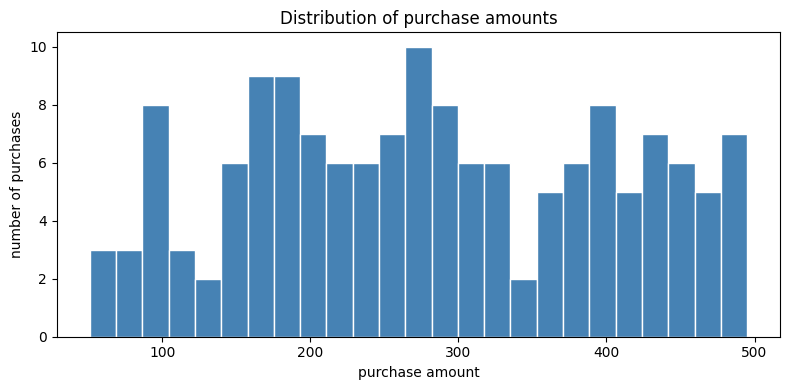

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(transactions['purchase_amount'], bins=25, color='steelblue', edgecolor='white')
ax.set_title('Distribution of purchase amounts')
ax.set_xlabel('purchase amount')
ax.set_ylabel('number of purchases')
plt.tight_layout(); plt.show()

### Which product categories are bought most?

This is our prediction target, so it matters how balanced it is. If one category
dominated, the model could just guess that category every time. This bar chart
lets us see how even the categories are.

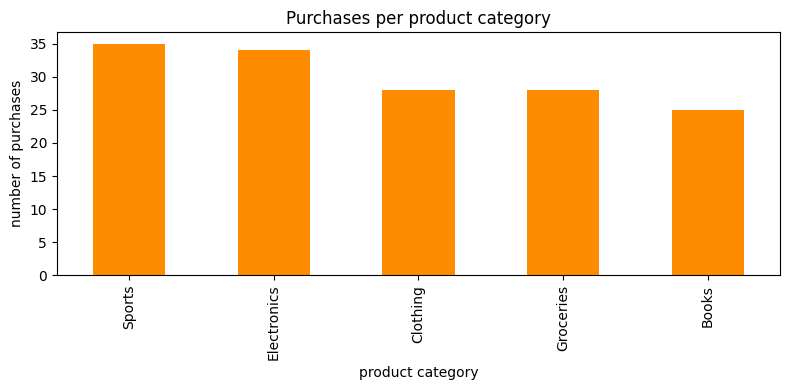

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
transactions['product_category'].value_counts().plot(kind='bar', color='darkorange', ax=ax)
ax.set_title('Purchases per product category')
ax.set_xlabel('product category')
ax.set_ylabel('number of purchases')
plt.tight_layout(); plt.show()

### Looking for outliers

A box plot is a quick way to spot values that sit far away from the rest. We look
at purchase amount and engagement score side by side. Any dots beyond the
whiskers are unusually high or low values worth being aware of.

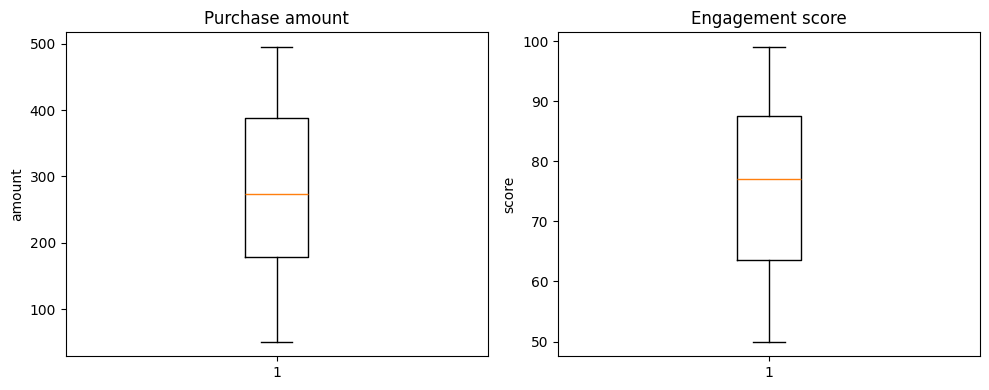

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.boxplot(transactions['purchase_amount'].dropna(), vert=True)
ax1.set_title('Purchase amount')
ax1.set_ylabel('amount')

ax2.boxplot(social['engagement_score'].dropna(), vert=True)
ax2.set_title('Engagement score')
ax2.set_ylabel('score')
plt.tight_layout(); plt.show()

### How do the social scores relate to each other?

This heatmap shows the correlation between the numeric social columns. A value
close to 1 (or -1) means two columns move together (or in opposite directions),
while a value near 0 means they are unrelated.

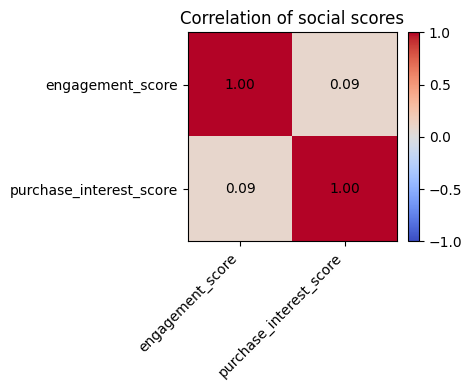

In [12]:
social_numeric = social[['engagement_score', 'purchase_interest_score']]
corr = social_numeric.corr()

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', color='black')
ax.set_title('Correlation of social scores')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

## 3. Clean the data

Now we fix the problems we found. We work on copies so the originals stay
untouched. There are three jobs: fill the missing ratings, turn the date text
into real dates, and remove any exact duplicate rows.

### Fill the missing ratings

A blank rating just means the customer did not leave one. We fill those gaps with
the middle (median) rating so the column has no holes, which keeps the later
model happy.

In [13]:
transactions_clean = transactions.copy()

median_rating = transactions_clean['customer_rating'].median()
transactions_clean['customer_rating'] = transactions_clean['customer_rating'].fillna(median_rating)

print('rating gaps before:', transactions['customer_rating'].isnull().sum())
print('rating gaps after :', transactions_clean['customer_rating'].isnull().sum())
print('filled with median:', median_rating)

rating gaps before: 10
rating gaps after : 0
filled with median: 3.0


### Turn the purchase date into a real date

Right now the date is text. Converting it to a real date lets us pull useful
pieces out of it later, like the month of the purchase.

In [14]:
transactions_clean['purchase_date'] = pd.to_datetime(transactions_clean['purchase_date'])
transactions_clean['purchase_date'].head()

0   2024-01-01
1   2024-01-02
2   2024-01-03
3   2024-01-04
4   2024-01-05
Name: purchase_date, dtype: datetime64[ns]

### Remove duplicate rows

We drop any rows that are exact copies. In the social file the same customer can
appear on several platforms, and that is fine, so we only remove rows where every
single value is identical.

In [15]:
social_clean = social.drop_duplicates().copy()

print('social rows before:', social.shape[0])
print('social rows after :', social_clean.shape[0])
print('transaction rows  :', transactions_clean.shape[0])

social rows before: 155
social rows after : 150
transaction rows  : 150


## 4. Merge the two datasets

Here is the key problem: the two files name the same customer differently. The
social file uses `A178` and the transactions file uses `178`. They are the same
person, so we build a matching key by taking the number out of the social id.

In [16]:
social_clean['customer_id'] = social_clean['customer_id_new'].str.replace('A', '', regex=False).astype(int)
transactions_clean['customer_id'] = transactions_clean['customer_id_legacy'].astype(int)

print('social ids sample     :', sorted(social_clean['customer_id'].unique())[:5])
print('transaction ids sample:', sorted(transactions_clean['customer_id'].unique())[:5])

social ids sample     : [100, 101, 102, 103, 104]
transaction ids sample: [100, 101, 102, 103, 104]


### Summarise the social profile per customer

A customer has several social rows (one per platform) but each purchase is a
single row. To join them cleanly we first squeeze each customer's social rows
into one summary row: their average engagement, average purchase interest, the
platform they use most, the sentiment they show most, and how many social rows
they have (a rough measure of how active they are).

In [17]:
def most_common(series):
    return series.value_counts().index[0]

social_summary = social_clean.groupby('customer_id').agg(
    avg_engagement=('engagement_score', 'mean'),
    avg_purchase_interest=('purchase_interest_score', 'mean'),
    main_platform=('social_media_platform', most_common),
    main_sentiment=('review_sentiment', most_common),
    social_activity=('customer_id', 'size'),
).reset_index()

social_summary.head()

,customer_id,avg_engagement,avg_purchase_interest,main_platform,main_sentiment,social_activity
0,100,77.000000,4.400000,Twitter,Negative,2
1,101,68.000000,1.000000,Twitter,Neutral,1
2,102,51.000000,4.800000,LinkedIn,Neutral,1
3,103,64.333333,2.866667,Instagram,Positive,3
4,104,83.000000,2.933333,Twitter,Negative,3


### Join the transactions to the social summary

We attach each customer's social summary onto every purchase they made. We use an
inner join so we only keep purchases where we actually know the customer's social
profile, which is exactly the group the model can reason about.

In [18]:
merged = transactions_clean.merge(social_summary, on='customer_id', how='inner')
print('merged shape:', merged.shape)
merged.head()

merged shape: (117, 12)


,customer_id_legacy,transaction_id,purchase_amount,purchase_date,product_category,customer_rating,customer_id,avg_engagement,avg_purchase_interest,main_platform,main_sentiment,social_activity
0,151,1001,408,2024-01-01,Sports,2.3,151,71.666667,2.166667,Twitter,Neutral,3
1,192,1002,332,2024-01-02,Electronics,4.2,192,60.000000,4.300000,Instagram,Positive,1
2,114,1003,442,2024-01-03,Electronics,2.1,114,87.000000,4.800000,Facebook,Negative,1
3,160,1005,64,2024-01-05,Clothing,1.3,160,72.666667,2.500000,TikTok,Neutral,3
4,120,1006,395,2024-01-06,Groceries,1.1,120,77.000000,2.666667,Instagram,Positive,3


## 5. Check the merge worked

A merge can silently drop or duplicate rows, so we check. We confirm how many
transactions found a matching profile, make sure no customer id went missing, and
check there are no empty cells left in the joined table.

In [19]:
print('transactions before merge:', transactions_clean.shape[0])
print('rows after merge         :', merged.shape[0])
print('matched                  :', merged.shape[0], 'of', transactions_clean.shape[0])
print('unmatched transactions   :', transactions_clean.shape[0] - merged.shape[0])

transactions before merge: 150
rows after merge         : 117
matched                  : 117 of 150
unmatched transactions   : 33


In [20]:
missing_after_merge = merged.isnull().sum()
missing_after_merge

customer_id_legacy       0
transaction_id           0
purchase_amount          0
purchase_date            0
product_category         0
customer_rating          0
customer_id              0
avg_engagement           0
avg_purchase_interest    0
main_platform            0
main_sentiment           0
social_activity          0
dtype: int64

Every purchase that had a known customer was matched, and the joined table has no
empty cells, so the merge is sound.

## 6. Engineer features for the model

The model works best with tidy numeric inputs, so we add a few helper columns.
We pull the month out of the date, turn the customer's sentiment into a number,
and add a simple flag for whether a purchase was large. These give the model more
to work with than the raw columns alone.

In [21]:
merged['purchase_month'] = merged['purchase_date'].dt.month

sentiment_map = {'Negative': -1, 'Neutral': 0, 'Positive': 1}
merged['sentiment_score'] = merged['main_sentiment'].map(sentiment_map)

big_purchase_line = merged['purchase_amount'].median()
merged['is_big_purchase'] = (merged['purchase_amount'] > big_purchase_line).astype(int)

merged[['purchase_date', 'purchase_month', 'main_sentiment', 'sentiment_score',
        'purchase_amount', 'is_big_purchase']].head()

,purchase_date,purchase_month,main_sentiment,sentiment_score,purchase_amount,is_big_purchase
0,2024-01-01,1,Neutral,0,408,1
1,2024-01-02,1,Positive,1,332,1
2,2024-01-03,1,Negative,-1,442,1
3,2024-01-05,1,Neutral,0,64,0
4,2024-01-06,1,Positive,1,395,1


### The finished table

This is the table the product recommendation model will train on. Each row is one
purchase, described by both the customer's shopping behaviour and their social
media behaviour, with `product_category` as the value we want to predict.

In [22]:
print('final shape:', merged.shape)
print('columns:')
for c in merged.columns:
    print(' -', c)

final shape: (117, 15)
columns:
 - customer_id_legacy
 - transaction_id
 - purchase_amount
 - purchase_date
 - product_category
 - customer_rating
 - customer_id
 - avg_engagement
 - avg_purchase_interest
 - main_platform
 - main_sentiment
 - social_activity
 - purchase_month
 - sentiment_score
 - is_big_purchase


## 7. Save the merged dataset

Finally we write the table to `data/processed/merged_dataset.csv` so the rest of
the project can load it straight away without repeating any of this work.

In [23]:
out_path = Path('data/processed/merged_dataset.csv')
out_path.parent.mkdir(parents=True, exist_ok=True)
merged.to_csv(out_path, index=False)
print('saved', merged.shape[0], 'rows to', out_path)

saved 117 rows to data/processed/merged_dataset.csv


## Summary

We started with two unconnected files and finished with one clean table ready for
modelling. Along the way we:

- explored both files with summary statistics and plots
- filled missing ratings, fixed the date column and removed duplicate rows
- solved the mismatched customer ids (`A178` vs `178`) to join the files
- checked the merge kept every matched purchase and left no empty cells
- added month, sentiment and big-purchase features

